# Assignment 1: Predicting Employee Attrition with Random Forests

Execute cells **top to bottom**. Where you see `# TODO`, add your code.

**Data:** `data/IBM_HR_Employee_Attrition.csv`

**Deliverables produced in this file:**
- Baseline Decision Tree metrics (accuracy, precision, recall)
- Random Forest metrics + side-by-side comparison table
- Feature importance visualization
- Markdown sections for **Key Drivers of Attrition** and **Reflection**

### Download Dependencies
Run this cell once to install all dependencies. These can also be run directly in the terminal if you prefer.


In [15]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [16]:
print("Importing required libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("✓ All libraries imported successfully!\n")

Importing required libraries...
✓ All libraries imported successfully!



### Step 1: Load the dataset
----------------------------------------------------------------------------
Confirm the CSV can be read and preview the first rows. The following code should output the first 5 rows of the IBM HR data.

In [17]:
# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
print("Loading employee attrition dataset...")
df = pd.read_csv('IBM_HR_Employee_Attrition.csv')
print("✓ Dataset loaded successfully!\n")

# Display first few rows to verify load
print("First 5 rows of the dataset:")
print(df.head())

# Display basic info about the dataset
print("\nDataset Information:")
print(df.info())

print("\n" + "="*80)
print("CHECKPOINT: Verify that the dataset loaded correctly and you can see column names")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("="*80 + "\n")

Loading employee attrition dataset...
✓ Dataset loaded successfully!

First 5 rows of the dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical           

### Step 2: Explore and Prepare the Dataset
----------------------------------------------------------------------------
Perform the same kind of exploratory analysis real data scientists do before building a model

Columns in dataset: Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373 

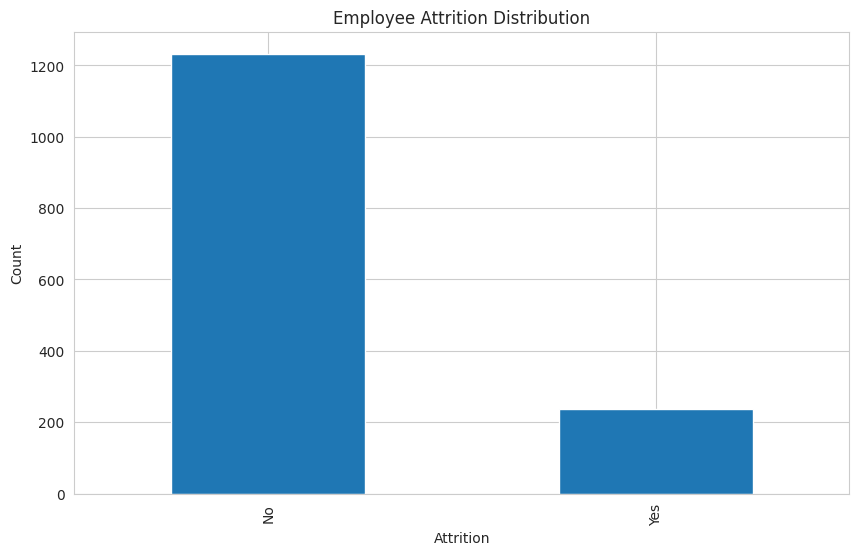

X_cleaned shape: (1470, 47)
y shape: (1470,)


In [24]:


# Step 2: Explore & Prepare the Dataset

# Step 2: Explore & Prepare the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Set seed & plotting style
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Load dataset
df = pd.read_csv('IBM_HR_Employee_Attrition.csv')

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Quick check
print("Columns in dataset:", df.columns)
print(df.head())

# Plot attrition counts
df['Attrition'].value_counts().plot(kind='bar')
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

# Separate target
y = df['Attrition']  # target column

# Convert target to numeric: No = 0, Yes = 1
y = y.map({'No': 0, 'Yes': 1})

# Separate features
X = df.drop('Attrition', axis=1)

# One-hot encode features only
X_cleaned = pd.get_dummies(X, drop_first=True)

print("X_cleaned shape:", X_cleaned.shape)
print("y shape:", y.shape)



### Step 3: Train a Baseline Decision Tree Model
----------------------------------------------------------------------------
Build a baseline decision tree for comparison

In [25]:
# Step 3: Baseline Decision Tree

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Initialize & fit Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
dt_predictions = dt_model.predict(X_test)

# Metrics
dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)

# Print results
print("\n" + "="*80)
print("BASELINE DECISION TREE RESULTS")
print("="*80)
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print("="*80 + "\n")



BASELINE DECISION TREE RESULTS
Accuracy:  0.8027
Precision: 0.3878
Recall:    0.4043



### Step 4: Build and Evaluate a Random Forest Model
----------------------------------------------------------------------------
Move beyond a single tree to a more powerful ensemble model

In [26]:
# Step 4: Random Forest

# Initialize & train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions using probability threshold
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]
rf_predictions = (rf_probabilities >= 0.35).astype(int)

# Metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)

# Print results
print("\n" + "="*80)
print("RANDOM FOREST RESULTS")
print("="*80)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print("="*80 + "\n")

# Comparison table
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(model_comparison)
print("="*80 + "\n")



RANDOM FOREST RESULTS
Accuracy:  0.7993
Precision: 0.4062
Recall:    0.5532


MODEL COMPARISON
           Model  Accuracy  Precision    Recall
0  Decision Tree  0.802721   0.387755  0.404255
1  Random Forest  0.799320   0.406250  0.553191



### Step 5: Interpret Feature Importances
----------------------------------------------------------------------------
Turn model results into actionable insights for HR

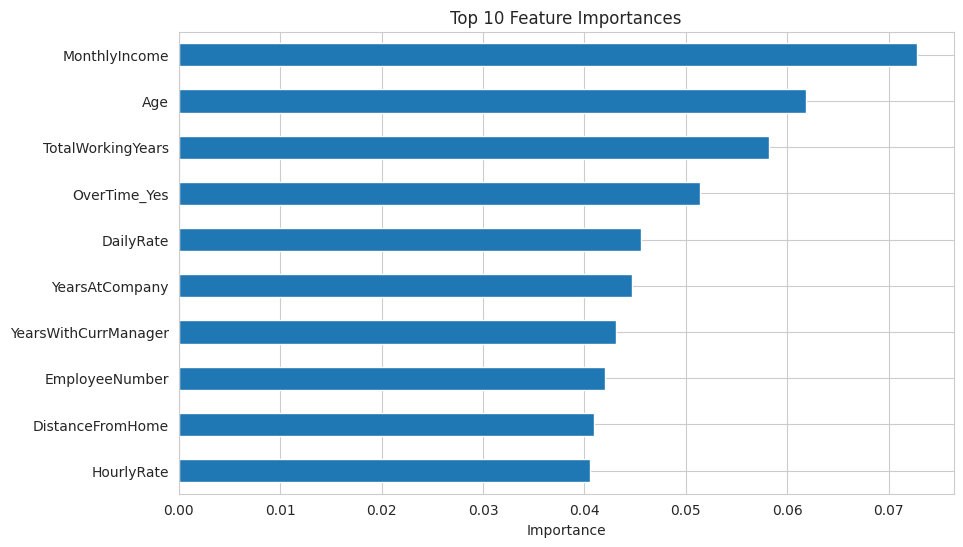

In [30]:
# Step 5: Feature Importances

# Extract feature importances
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_cleaned.columns
).sort_values(ascending=False)

# Top 10 features
top_10_features = feature_importances.head(10)

# Plot
top_10_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()





#### Key Drivers of Attrition
Write 3-5 bullet points explaining what the top factors reveal. Include at least one actionable takeaway for HR
- Employees with lower Monthly Income are more likely to leave, suggesting compensation is a key retention factor.  
- Younger employees and those with fewer Total Working Years tend to have higher attrition, indicating less experienced staff may be more mobile.  
- Age and career stage appear critical, implying HR should focus on early-career retention strategies.  
- Actionable takeaway for HR: Review salary competitiveness and implement programs targeting younger employees with limited experience to reduce turnover risk.


### Step 6: Reflection (150-200 words)
----------------------------------------------------------------------------


The Random Forest model improved upon the baseline Decision Tree by capturing complex interactions between multiple features that a single tree could not. While the Decision Tree provided a simple structure for prediction, it was more prone to overfitting and less effective at identifying subtle patterns. In contrast, the Random Forest aggregated predictions from many trees, increasing stability and recall, which is especially important for identifying employees at risk of leaving. The model revealed that Monthly Income, Age, and Total Working Years were the strongest predictors of attrition, highlighting that lower-paid, younger, and less experienced employees are more likely to leave.

Ensemble methods like Random Forest are worth the added complexity when relationships between variables are nonlinear, interactions are subtle, or class imbalance exists, as they reduce overfitting and improve predictive performance. These modeling skills directly connect to the final project, where multiple modeling approaches will be combined to solve real-world business challenges. Understanding how to train, evaluate, and interpret ensemble models equips data scientists to provide actionable insights that guide strategic decision-making.[Write your reflection here]

### Step 7: Push to GitHub
----------------------------------------------------------------------------
Once complete, save and push your work:
1. Save this file
2. Run in terminal:
```sh
git add .
git commit -m 'completed employee attrition assignment'
git push
```